In [22]:
from dotenv import load_dotenv #import 
import os 

load_dotenv("../../.env")

True

In [23]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

from typing import Literal, Annotated, List, Any
from IPython.display import Image, display
from jinja2 import Template
from operator import add
import cohere
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, convert_to_openai_messages, HumanMessage
from langgraph.types import Send
from langchain_openai import ChatOpenAI
import openai
import pandas as pd
from qdrant_client import QdrantClient, models

from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from ast import MatchValue
from tracemalloc import Filter
import cohere
from langsmith import traceable, get_current_run_tree
import instructor
from api.agents.utils.prompt_management import prompt_template_config

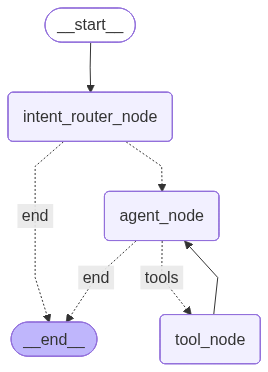

In [24]:
@traceable(
    name="embed_query",
    run_type="embedding", # tells langsmith we are actually running embedding text -> specific set of vectors
    metadata={
        "ls_provider": "openai", 
              "model": "text-embedding-3-small"
    } ## langsmith needs this to calculate cost of runs
)
def get_embedding(text):
    response = openai.embeddings.create( # was client before
        input=text,
        model="text-embedding-3-small"
    )
    
    current_run  = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }
    return response.data[0].embedding

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True): # 5 most similar items to users query
    embedding = get_embedding(query) # so we are actually creating related vector here
    
    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=embedding,
                    using='text-embedding-3-small', #name of the vector in the collection
                    limit=20
                ), 
                Prefetch(
                    query=Document(text=query, model='qdrant/bm25'),
                    using='bm25', #name of the vector in the collection
                    limit=20
                )
            ],
            # can set specific weights on how much importance we put on dense embeddings and bm25 lexical retrievals
            # in this case dense vector retrival is weighted as 3 times more important than bm25
            # if user queries are more keyword-based, you might want to increase the weight of bm25
            # if more contextual then you might want to increase the weight of the dense vector retrieval
            # weights can be added as params to the retrieve data function
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])), # how you fuse the results....
            limit=k # once fused we are returning top k results
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=embedding,
            using='text-embedding-3-small',
            limit=k
        )
    
    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload.get("preprocessed_description"))
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload.get("average_rating"))
    
    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

@traceable(
    name="rerank_data",
    run_type="tool"
)
def rerank_data(query, context, topk_k=5):
    cohere_client = cohere.ClientV2()
    # so we pass the query and the array of preprocessed_description name, desc context chunks
    response = cohere_client.rerank(
        model="rerank-v3.5",
        query=query,
        documents=context['retrieved_context'],
        top_n=topk_k
    )
    order = [result.index for result in response.results]
    # re order the original context
    return {
        "retrieved_context_ids": [context["retrieved_context_ids"][i] for i in order],
        "retrieved_context": [context["retrieved_context"][i] for i in order],
        "similarity_scores": [context["similarity_scores"][i] for i in order],
        "retrieved_context_ratings": [context["retrieved_context_ratings"][i] for i in order]
    }
    
@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):
    formatted_context = ""
    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    return formatted_context

class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of item used to answer the question")
    description: str = Field(description="Description of item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="The final answer to the user's query, generated by the model after tool usage.")
    references: List[RAGUsedContext] = Field(description="A list of items from the retrieved context that were used to generate the final answer, including their IDs and descriptions.")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: List[RAGUsedContext] = []
    

# runs retrieval for query
# first hybrid then rerank
@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:
    """Get the top k context, each representing an inventory item for a given query.

    Args:
        query: The query to get the top k context for
        top_k: The number of context chunks to retrieve, works best with 5 or more

    Returns:
        A string of the top k context chunks with IDs and average ratings prepending each chunk, each representing an inventory item for a given query.
    """
    qdrant_client = QdrantClient(url="http://localhost:6333")
    retrievedContext = retrieve_data(
        query, 
        qdrant_client, 
        k=20
    )
    # if we set rerank to True, we re-order the retrieved context based on the reranker results
    retrievedContext = rerank_data(query, retrievedContext, topk_k=top_k)
    formatted_context = process_context(retrievedContext)
    return formatted_context

traceable(
    name="agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini",
    }
)
def agent_node(state: State) -> dict: # agent node always gets state object
    # jinja template for the prompt that we will send to the llm
    # teh agent needs to see what has been done ...
    prompt_template = """
        You are a shopping assistant that answers customer questions about products currently in stock.

        ## Instructions

        - Use the available tools to answer product questions. Do not fabricate product details.
        - When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
        - When describing products, include detailed specifications in bullet points.
        - If tools return no relevant results, tell the customer and ask them to refine their query.
        - Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they're interested in.
        - In references, include every chunk that contributed to your answer with the chunk id and product name.
        - Refer to retrieved data as "available products", never as "context".
        - Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
    """
    
    template = Template(prompt_template) ## create a jinja template object
    prompt = template.render() ## render the template with the query from the
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        reasoning_effort = "low",
        use_responses_api = True # we cannot use completions api ... (indicates augmented llm) 
    )

    # tools can be functions or pydantic models
    llm_with_tools = llm.bind_tools(
        [get_formatted_item_context, FinalResponse], # we can also return a final response from the model instead of going through the graph again (this is useful for when we want to return a final answer to the user instead of going through the graph again)
        tool_choice="any" # auto means llm can suggest or not suggest the tool (any forces the llm to suggest any of the tools provided in the toolset)
    )

    response = llm_with_tools.invoke([
        SystemMessage(content=prompt), ## open ais abstractioon on creating a message object from a string (llm only takes in messages objects as input so we need to convert our prompt into a message object),
        *state.messages ## we also want to pass in the message history so that the model can see what has been done in previous iterations
    ])
    
    final_answer = False
    answer = ""
    references = []
    
    if(len(response.tool_calls) > 0):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                references.extend(tool_call.get("args").get("references"))
                answer = tool_call.get("args").get("answer")
                
    # response.tool_calls.... 
    return {
        "messages": [response], # appended with new response
        "final_answer": final_answer,
        "iteration": state.iteration + 1,
        "answer": answer,
        "references": references
    }
    
def tool_router(state: State) -> str:
    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    if len(state.messages[-1].tool_calls) > 0: # if the model called a tool we want to go to the agent node again to see if it wants to call another tool
        return "tools"
    else:
        return "end"


class IntentRouterResponse(BaseModel):
    question_relevant: bool = Field(description="Whether the user's question is relevant to the products in the database")
    answer: str = Field(description="A brief explanation of why the question is relevant or not.")

@traceable(
    name="route_intent", 
    run_type = 'llm',
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini",
    }
)
def intent_router_node(state: State) -> dict:
    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.
        ## Instructions

        - Determine whether the question is about products, inventory, or purchasing.
        - Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
        - Questions about store policies, personal advice, or unrelated topics are not relevant.

        ## Examples

        Question: "Do you have running shoes under $100?"
        Relevant: yes

        Question: "What's the weather like today?"
        Relevant: no - not related to products

        Question: "Can you help me write an essay?"
        Relevant: no - not related to products

        Question: "Which laptop has the best battery life?"
        Relevant: yes

        Question: "What's your return policy?"
        Relevant: no - about store policy, not product information
    """
        
    template = Template(prompt_template)
    prompt = template.render()
    messages = state.messages
    conversation = []
    for message in messages:
        conversation.append(convert_to_openai_messages(message))
    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode=instructor.Mode.RESPONSES_TOOLS
    )
    
    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        reasoning={"effort": "none"},
        response_model = IntentRouterResponse
    )
    
    print("Intent Router Response:", response)
    
    return {
        "question_relevant": response.question_relevant, # pydantic class
        "answer": response.answer
    }
    

def intent_router_conditional_edges(state: State) -> str:
    if state.question_relevant:
        return "agent_node"
    else:
        return "end"


workflow = StateGraph(State)
tools = [get_formatted_item_context]
tool_node = ToolNode(tools)


workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node", # agent node conditionally routes to either tool node or end through tool router
    tool_router, 
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", "agent_node") # after the tool node we want to go back to the agent node to see if the model wants to call another tool

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [25]:
initial_state = {
    "messages": [HumanMessage(content="Can i get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker")]
}

result = graph.invoke(initial_state)

Intent Router Response: question_relevant=True answer='The request is about purchasing multiple electronics (tablet, smartwatch, laptop, and waterproof speaker), which relates to available products and recommendations.'


In [26]:
result

{'messages': [HumanMessage(content='Can i get a tablet for my kid, a watch for me, a laptop for my wife and a waterproof speaker', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'id': 'rs_079ca890b2d6fb3d006a52be3e7510819a94896012c44d2cbd', 'summary': [], 'type': 'reasoning', 'content': []}, {'arguments': '{"query":"tablet for a kid or children\'s tablet in stock", "top_k":5}', 'call_id': 'call_vS0Yn4IVpqu0jkOK5VsT1xxa', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_079ca890b2d6fb3d006a52be3f2874819aa7bb8afaf2e40da5', 'status': 'completed'}, {'arguments': '{"query":"watch for adults in stock", "top_k":5}', 'call_id': 'call_pm2P1dqOP9m8hK4AJXdWSWrE', 'name': 'get_formatted_item_context', 'type': 'function_call', 'id': 'fc_079ca890b2d6fb3d006a52be3f2884819aaec1339de487758a', 'status': 'completed'}, {'arguments': '{"query":"laptop for wife in stock", "top_k":5}', 'call_id': 'call_l2nwwljnpWqfDyLGZBsU5f1u', 'name': 'get_formatted_item_context'

In [27]:
print(result["answer"])

Here are some available products that fit what you’re looking for:

**Tablet for your kid**
- **KYASTER Kids Tablet (7", Android 12)**
  - 7-inch Full HD 1920×1200 IPS display
  - Android 12 Go OS
  - 2GB RAM, 32GB storage
  - Parental controls and kid-safe EVA case
  - Stylus included
  - Good for learning, videos, and age-appropriate apps
- **G-TiDE Kids Tablet (7", Pink or Blue)**
  - 7-inch tablet for ages 3–7
  - 32GB storage, 2GB RAM
  - Parental controls, kid-proof EVA case, shoulder strap
  - Dual camera, Android tablet with Google Play access

**Watch for you**
- **Military Smart Watch Men, 5 ATM Waterproof Tactical Watch**
  - 5 ATM waterproof, suitable for water exposure up to 50m
  - Bluetooth calling, answer/make calls
  - Heart rate, SpO2, sleep tracking
  - 20 sports modes and rugged build
- **ASWEE Smart Watch, 5 ATM Waterproof Fitness Tracker**
  - 1.10" AMOLED display
  - 5 ATM water resistance
  - Sleep monitoring, activity tracking, smart notifications
  - Compatibl